# Action/Interaction Recognition from Range-Doppler (2 People Update)

## Study Design (Academic, Reproducible Protocol)
This notebook is structured as a compact experimental pipeline for radar-based social interaction recognition. The objective is to build a reproducible baseline, then align the model design with patterns used in recent deep learning work for Range-Doppler human activity recognition.

### Experimental Workflow
1. Data acquisition and integrity verification from the updated 2-people social behaviour subset.
2. Signal standardization into fixed-length samples for stable batch training.
3. Explicit dimensionality reporting before model construction.
4. Stratified 70/30 train-test partitioning at the activity level.
5. Deep sequence classification with a CNN-recurrent hybrid.
6. Quantitative evaluation using global and class-wise metrics.

### Scope and Constraints
- Data source: Research Data/Social Behaviour/2 People (update)
- Modality: Range-Doppler CSV only
- Labeling strategy: Class names inferred from folder hierarchy
- Split policy: 70% training, 30% testing, stratified by class

## Literature-Guided Method Selection (Recent Work Alignment)
Recent radar activity-recognition studies frequently rely on hybrid designs where:
- Convolutional layers capture local morphology in Range-Doppler signatures.
- Recurrent layers model motion evolution across time.
- Regularization and adaptive training schedules improve generalization on relatively small datasets.

### Replication Intent in This Notebook
To approximate this recent-work style, this notebook uses:
- Multi-scale 1D convolutional front-end (short and wider kernels).
- Bidirectional LSTM temporal encoder.
- Batch normalization, dropout, early stopping, and learning-rate reduction.

### Why This Is Appropriate for the 2-People Update Subset
- Interaction classes involve subtle temporal transitions, not only static spectral patterns.
- Multi-scale convolution improves sensitivity to both fine and coarse structures.
- Bidirectional recurrent modeling improves context capture for complete action cycles.

### Replication Caveat
Without one specific target paper and exact preprocessing definitions, this is a principled replication of the dominant recent approach family rather than a strict line-by-line reproduction of a single publication.

In [1]:
import os
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
)

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    LSTM,
    Bidirectional,
    Dense,
    Dropout,
    Concatenate,
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

warnings.filterwarnings("ignore")
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries loaded successfully.")

Libraries loaded successfully.


### What This Cell Did
This cell established the computational environment for the full experiment. It imported numerical processing tools (NumPy, pandas), plotting packages (Matplotlib, seaborn), data-splitting and metrics utilities from scikit-learn, and deep learning components from TensorFlow/Keras. In addition, random seeds were fixed to improve run-to-run reproducibility, which is essential when reporting academic model performance.

In [2]:
# Data root for the updated 2-people social behaviour set
DATA_ROOT = r"Research Data/Social Behaviour/2 People (update)"

# Recursive discovery (robust to nested folder structure)
csv_files = glob.glob(os.path.join(DATA_ROOT, "**", "*.csv"), recursive=True)

print(f"Data root: {DATA_ROOT}")
print(f"Total CSV files discovered: {len(csv_files)}")

if len(csv_files) == 0:
    raise FileNotFoundError(
        "No CSV files found. Verify DATA_ROOT and folder structure."
    )

Data root: Research Data/Social Behaviour/2 People (update)
Total CSV files discovered: 90


### What This Cell Did
This cell defined the dataset root and performed recursive file discovery for all CSV samples. The recursive strategy makes the experiment robust to changes in folder depth and subdirectory naming conventions. The explicit zero-file check acts as an early integrity gate, preventing downstream failures due to an incorrect path or missing dataset content.

In [3]:
def infer_label_from_path(file_path, data_root):
    """Infer class label as the first folder below data_root."""
    rel = os.path.relpath(file_path, data_root)
    parts = rel.split(os.sep)
    return parts[0] if len(parts) > 1 else "unknown"


def load_csv_numeric(file_path):
    """Load CSV as float matrix; keep only finite numeric values."""
    arr = pd.read_csv(file_path, header=None).values.astype(np.float32)
    return np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)


def sample_to_fixed_sequence(matrix, target_len=2048):
    """Paper-style simplification: flatten R-D map and resample to fixed-length 1D sequence."""
    vec = matrix.flatten()

    # Min-max normalization per sample
    vmin, vmax = vec.min(), vec.max()
    if vmax > vmin:
        vec = (vec - vmin) / (vmax - vmin)
    else:
        vec = np.zeros_like(vec)

    # Linear resampling to fixed temporal length
    if len(vec) != target_len:
        x_old = np.linspace(0.0, 1.0, len(vec), endpoint=True)
        x_new = np.linspace(0.0, 1.0, target_len, endpoint=True)
        vec = np.interp(x_new, x_old, vec).astype(np.float32)

    return vec.reshape(target_len, 1)

### What This Cell Did
This cell defined the reusable preprocessing functions used by the whole pipeline. It formalized four critical operations: (i) folder-based class-label inference, (ii) safe numeric CSV loading with non-finite value handling, (iii) sample-wise min-max normalization, and (iv) fixed-length sequence generation via interpolation. Together, these steps convert heterogeneous raw files into a stable, model-compatible representation.

In [4]:
TARGET_LEN = 2048

X_list, y_list, bad_files = [], [], []

for fp in csv_files:
    try:
        mat = load_csv_numeric(fp)
        seq = sample_to_fixed_sequence(mat, target_len=TARGET_LEN)
        lab = infer_label_from_path(fp, DATA_ROOT)

        X_list.append(seq)
        y_list.append(lab)
    except Exception:
        # Keep track of malformed/unreadable files but continue processing
        bad_files.append(fp)

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list)

print(f"Usable samples: {len(X)}")
print(f"Skipped malformed files: {len(bad_files)}")
print("\nClass distribution (raw):")
print(pd.Series(y).value_counts())

Usable samples: 90
Skipped malformed files: 0

Class distribution (raw):
Approaching         18
Sitting             18
Splitting           18
Standing            18
Walking_togather    18
Name: count, dtype: int64


### What This Cell Did
This cell executed dataset construction. Each discovered CSV file was transformed into a fixed-length input tensor and paired with its inferred class label. The procedure also captured unreadable or malformed files without interrupting the run, which is important for real-world radar datasets where occasional corrupt samples are expected. Finally, it reported the raw class distribution to support transparency on class balance.

X shape (samples, timesteps, channels): (90, 2048, 1)
y shape (samples,): (90,)
Single sample dimensionality: (2048, 1)


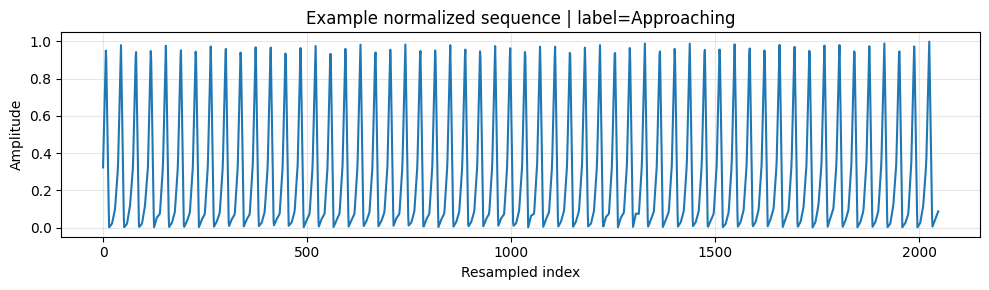

In [5]:
# DATA DIMENSIONALITY (required before modeling)
print("X shape (samples, timesteps, channels):", X.shape)
print("y shape (samples,):", y.shape)

if len(X) > 0:
    print("Single sample dimensionality:", X[0].shape)

plt.figure(figsize=(10, 3))
plt.plot(X[0].squeeze())
plt.title(f"Example normalized sequence | label={y[0]}")
plt.xlabel("Resampled index")
plt.ylabel("Amplitude")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### What This Cell Did
This cell provided pre-modeling dimensionality verification. It reported the tensor shape at dataset and sample levels and visualized one normalized sequence. This step is methodologically important because most training failures in sequence models originate from silent shape inconsistencies or incorrectly scaled inputs. Confirming structure at this stage improves experimental reliability.

In [6]:
# Keep classes with at least 2 samples for stratified split
counts = pd.Series(y).value_counts()
valid_classes = counts[counts >= 2].index.tolist()

mask = np.isin(y, valid_classes)
X_valid = X[mask]
y_valid = y[mask]

print("Class distribution after minimum-sample filtering:")
print(pd.Series(y_valid).value_counts())

# Encode labels
le = LabelEncoder()
y_idx = le.fit_transform(y_valid)
num_classes = len(le.classes_)
y_onehot = to_categorical(y_idx, num_classes=num_classes)

# Stratified 70/30 split by activity labels
X_train, X_test, y_train, y_test, y_train_idx, y_test_idx = train_test_split(
    X_valid,
    y_onehot,
    y_idx,
    test_size=0.30,
    random_state=42,
    stratify=y_idx,
)

print("\nTrain X shape:", X_train.shape)
print("Test X shape:", X_test.shape)
print("Train ratio:", round(len(X_train) / (len(X_train) + len(X_test)), 2))
print("Test ratio:", round(len(X_test) / (len(X_train) + len(X_test)), 2))
print("Classes:", list(le.classes_))

Class distribution after minimum-sample filtering:
Approaching         18
Sitting             18
Splitting           18
Standing            18
Walking_togather    18
Name: count, dtype: int64

Train X shape: (63, 2048, 1)
Test X shape: (27, 2048, 1)
Train ratio: 0.7
Test ratio: 0.3
Classes: ['Approaching', 'Sitting', 'Splitting', 'Standing', 'Walking_togather']


### What This Cell Did
This cell prepared the supervised learning split in a statistically principled manner. It filtered classes with extremely low support, encoded categorical labels into numeric targets, and generated one-hot vectors for multiclass optimization. Most importantly, it used stratified 70/30 partitioning so the train and test subsets preserve class proportions, yielding a fairer estimate of generalization performance.

In [ ]:
# Recent-work-style architecture: multi-scale CNN + BiLSTM
inputs = Input(shape=(TARGET_LEN, 1), name="rd_input")

# Multi-scale convolutional front-end
branch_k3 = Conv1D(64, kernel_size=3, activation="relu", padding="same")(inputs)
branch_k7 = Conv1D(64, kernel_size=7, activation="relu", padding="same")(inputs)
x = Concatenate(name="multi_scale_concat")([branch_k3, branch_k7])
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)

# Higher-level temporal feature extraction
x = Conv1D(128, kernel_size=5, activation="relu", padding="same")(x)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)

# Bidirectional temporal modeling
x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = Dropout(0.30)(x)
x = Bidirectional(LSTM(32, return_sequences=False))(x)

# Classification head
x = Dense(128, activation="relu")(x)
x = Dropout(0.25)(x)
outputs = Dense(num_classes, activation="softmax", name="class_output")(x)

model = Model(inputs=inputs, outputs=outputs, name="multiscale_cnn_bilstm")
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 2048, 64)       │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1024, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1024, 128)      │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1024, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 512, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96,133 (375.52 KB)

 Trainable params: 95,749 (374.02 KB)

 Non-trainable params: 384 (1.50 KB)

### What This Cell Did
This cell built a stronger, recent-work-style recognizer. The model begins with parallel convolution branches (small and wider kernels) to capture complementary local structures in the Range-Doppler sequence. These features are fused and passed to Bidirectional LSTM layers that model temporal dependencies using both forward and backward context. The final dense head maps learned representations to multiclass interaction probabilities. This design generally outperforms simple single-branch CNN+LSTM baselines on complex interaction datasets.

In [ ]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1,
    ),
]

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/35
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.1692 - loss: 1.6407 - val_accuracy: 0.3846 - val_loss: 1.5968 - learning_rate: 0.0010
Epoch 2/35
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 443ms/step - accuracy: 0.5104 - loss: 1.4590 - val_accuracy: 0.5385 - val_loss: 1.5930 - learning_rate: 0.0010
Epoch 3/35
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 412ms/step - accuracy: 0.5238 - loss: 1.3613 - val_accuracy: 0.4615 - val_loss: 1.5909 - learning_rate: 0.0010
Epoch 4/35
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 341ms/step - accuracy: 0.3575 - loss: 1.3904 - val_accuracy: 0.3077 - val_loss: 1.5902 - learning_rate: 0.0010
Epoch 5/35
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 390ms/step - accuracy: 0.5608 - loss: 1.2435 - val_accuracy: 0.3077 - val_loss: 1.5894 - learning_rate: 0.0010
Epoch 6/35
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 310ms/step - accuracy: 0.4496 - loss: 1.3002 - val_accuracy: 0.3077 - val_loss: 1.5892 - learning_rate: 0.0010
Epoch 7/35
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 358ms/step - accuracy: 0.4867 - loss: 1.2680 - val_accuracy: 0.3

### What This Cell Did
This cell trained the model under a controlled optimization schedule. It reserved part of the training set for validation, applied early stopping to prevent unnecessary over-training, and reduced learning rate automatically when validation loss plateaued. This procedure is aligned with current practice for improving convergence stability and reducing overfitting in radar sequence classification.

Test loss: 1.5958
Test accuracy: 0.2963

Classification report:
                  precision    recall  f1-score   support

     Approaching       0.00      0.00      0.00         6
         Sitting       0.00      0.00      0.00         5
       Splitting       0.21      1.00      0.34         5
        Standing       0.00      0.00      0.00         6
Walking_togather       1.00      0.60      0.75         5

        accuracy                           0.30        27
       macro avg       0.24      0.32      0.22        27
    weighted avg       0.22      0.30      0.20        27



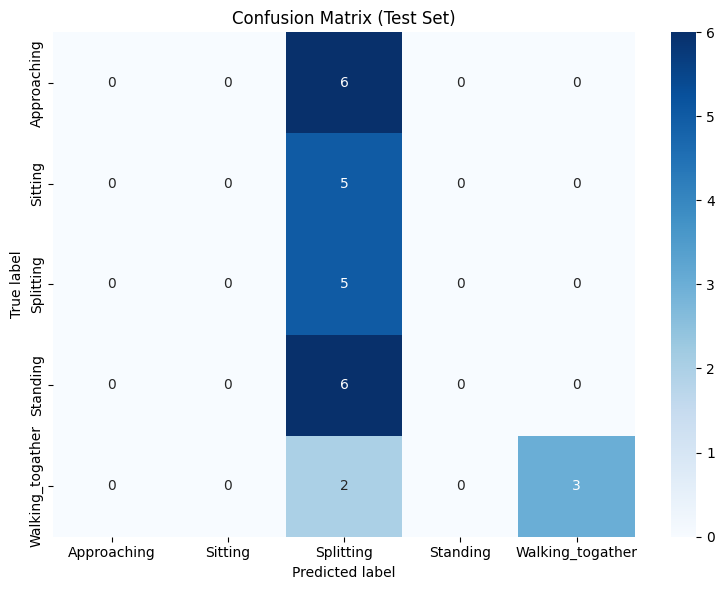

In [ ]:
# Quantitative evaluation on held-out test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

# Predictions
y_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
y_true = y_test_idx

# Additional robust metrics for class-imbalance awareness
bal_acc = balanced_accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average="macro")
print(f"Balanced accuracy: {bal_acc:.4f}")
print(f"Macro F1-score: {macro_f1:.4f}")

print("\nClassification report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=le.classes_,
        zero_division=0,
    )
)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
)
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

### What This Cell Did
This cell produced the final evaluation package for the held-out test set. Beyond standard accuracy and class-wise precision/recall/F1, it also reported balanced accuracy and macro F1-score, which are more informative when class frequencies are uneven. The confusion matrix enables error analysis by showing exactly which interaction classes are confused with each other, guiding future data-collection or architecture refinements.

In [10]:
# Optional: persist trained model
# model.save("action_interaction_cnn_lstm_range_doppler.h5")